# **Notebook Deep Learning Assignment 1**
**11 September 2026** <br> <br>
Nama : Nicholas Lim <br>
NIM : 24/543264/PA/23075

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
train = pd.read_excel("/content/drive/MyDrive/Deep Learning Assignment 1/Deep Learning Notebook.xlsx", sheet_name="Training")
val = pd.read_excel("/content/drive/MyDrive/Deep Learning Assignment 1/Deep Learning Notebook.xlsx", sheet_name="Validation")

In [ ]:
X_train = train[["X1", "X2", "X3", "X4"]].values
y_train = train["TARGET"].values
X_val = val[["X1", "X2", "X3", "X4"]].values
y_val = val["TARGET"].values
lr = 0.1
epochs = 5

In [ ]:
print("Jumlah data Training: ", len(X_train))
print("Jumlah data Validation: ", len(X_val))
train, val

Jumlah data Training:  80
Jumlah data Validation:  20


(    No   X1   X2   X3   X4  TARGET
 0    1  5.1  3.5  1.4  0.2       0
 1    2  4.9  3.0  1.4  0.2       0
 2    3  4.7  3.2  1.3  0.2       0
 3    4  4.6  3.1  1.5  0.2       0
 4    5  5.0  3.6  1.4  0.2       0
 ..  ..  ...  ...  ...  ...     ...
 75  76  6.0  3.4  4.5  1.6       1
 76  77  6.7  3.1  4.7  1.5       1
 77  78  6.3  2.3  4.4  1.3       1
 78  79  5.6  3.0  4.1  1.3       1
 79  80  5.5  2.5  4.0  1.3       1
 
 [80 rows x 6 columns],
     No   X1   X2   X3   X4  TARGET
 0    1  5.0  3.5  1.3  0.3       0
 1    2  4.5  2.3  1.3  0.3       0
 2    3  4.4  3.2  1.3  0.2       0
 3    4  5.0  3.5  1.6  0.6       0
 4    5  5.1  3.8  1.9  0.4       0
 5    6  4.8  3.0  1.4  0.3       0
 6    7  5.1  3.8  1.6  0.2       0
 7    8  4.6  3.2  1.4  0.2       0
 8    9  5.3  3.7  1.5  0.2       0
 9   10  5.0  3.3  1.4  0.2       0
 10  11  5.5  2.6  4.4  1.2       1
 11  12  6.1  3.0  4.6  1.4       1
 12  13  5.8  2.6  4.0  1.2       1
 13  14  5.0  2.3  3.3  1.0       1
 1

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def step(w, x, t):
    z = w[0] + np.dot(w[1:], x)
    g = sigmoid(z)
    pred = 1.0 if g > 0.5 else 0.0
    err = g - t
    sse = err ** 2
    dbias = 2 * err * (1 - g) * g
    dw = np.array([dbias, *(dbias * x)])
    return pred, sse, dw

w = np.array([0.5] * 5)
epoch_val_weight = {}

In [ ]:
train_mse, train_acc, train_tp, train_tn = [], [], [], []
for e in range(1, epochs + 1):
    sse_total, tp, tn = 0, 0, 0
    for i in range(len(X_train)):
        pred, sse, dw = step(w, X_train[i], y_train[i])
        sse_total += sse
        tp += (pred == 1 and y_train[i] == 1)
        tn += (pred == 0 and y_train[i] == 0)
        w = w - lr * dw
    epoch_val_weight[e] = w.copy()

    train_mse.append(sse_total / len(X_train))
    train_acc.append((tp + tn) / len(X_train))
    train_tp.append(tp)
    train_tn.append(tn)

In [ ]:
print("Nilai akhir tiap epoch (bias, teta1, teta2, teta3, teta4):")
for e in range(1, epochs + 1):
    print(e, epoch_val_weight[e])

Nilai akhir tiap epoch (bias, teta1, teta2, teta3, teta4):
1 [ 0.38033612 -0.01913312  0.07144656  0.52444933  0.55114017]
2 [ 0.34247243 -0.09319455 -0.07615825  0.7072215   0.63643854]
3 [ 0.31041811 -0.15226599 -0.2037863   0.86571089  0.70933991]
4 [ 0.28227383 -0.20186001 -0.3181515   1.00254085  0.77078769]
5 [ 0.25771975 -0.24180165 -0.41690349  1.1222139   0.82405866]


In [ ]:
val_mse, val_acc, val_tp, val_tn = [], [], [], []
for e in range(1, epochs + 1):
    wv = epoch_val_weight[e]
    sse_total, tp, tn = 0, 0, 0
    for i in range(20):
        pred, sse, dw = step(wv, X_val[i], y_val[i])
        sse_total += sse
        tp += (pred == 1 and y_val[i] == 1)
        tn += (pred == 0 and y_val[i] == 0)

    val_mse.append(sse_total / len(X_val))
    val_acc.append((tp + tn) / len(X_val))
    val_tp.append(tp)
    val_tn.append(tn)

In [ ]:
train_table = pd.DataFrame({
    "epoch": list(epochs_range), "mse": train_mse,
    "tp": train_tp, "tn": train_tn, "total": len(X_train), "accuracy": train_acc,
})

print("\nTabel Training:")
print(train_table.to_string(index=False))


Tabel Training:
 epoch      mse  tp  tn  total  accuracy
     1 0.449889  39   3     80    0.5250
     2 0.037452  38  38     80    0.9500
     3 0.024372  39  39     80    0.9750
     4 0.017357  39  39     80    0.9750
     5 0.012740  39  40     80    0.9875


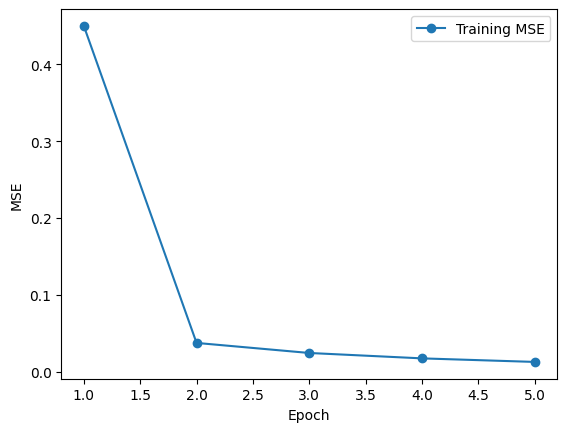

In [ ]:
epochs_range = range(1, epochs + 1)

plt.plot(epochs_range, train_mse, marker='o', label='Training MSE')
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.show()

In [ ]:
val_table = pd.DataFrame({
    "epoch": list(epochs_range), "mse": val_mse,
    "tp": val_tp, "tn": val_tn, "total": len(X_val), "accuracy": val_acc,
})

print("\nTabel Validation:")
print(val_table.to_string(index=False))


Tabel Validation:
 epoch      mse  tp  tn  total  accuracy
     1 0.328951  10   0     20      0.50
     2 0.247289  10   0     20      0.50
     3 0.175892  10   0     20      0.50
     4 0.119381  10   7     20      0.85
     5 0.081581  10  10     20      1.00


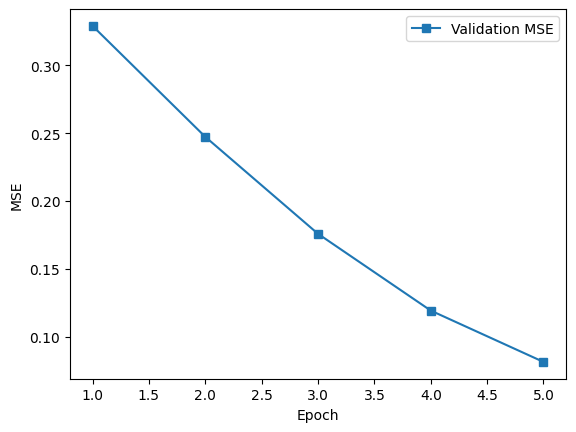

In [ ]:
plt.plot(epochs_range, val_mse, marker='s', label='Validation MSE')
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.show()

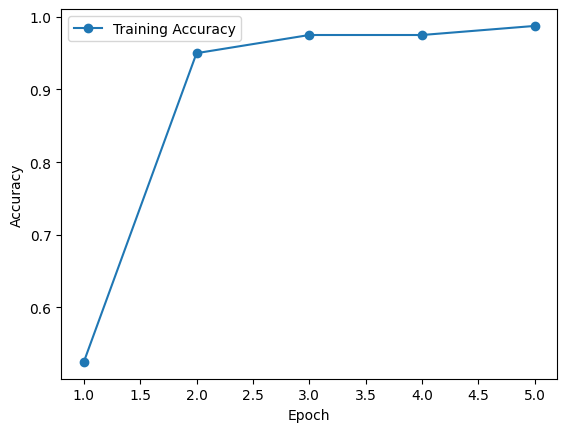

In [ ]:
plt.plot(epochs_range, train_acc, marker='o', label='Training Accuracy')
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()

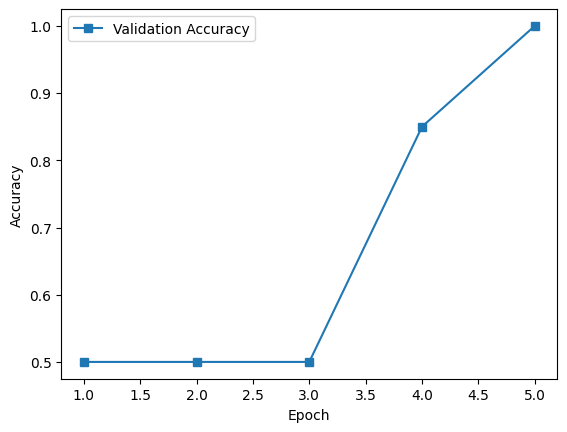

In [ ]:
plt.plot(epochs_range, val_acc, marker='s', label='Validation Accuracy')
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()

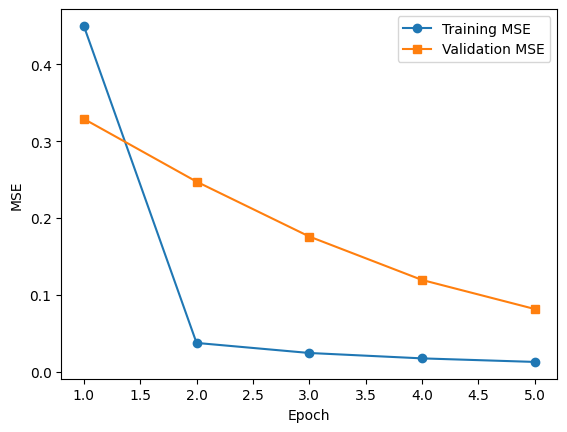

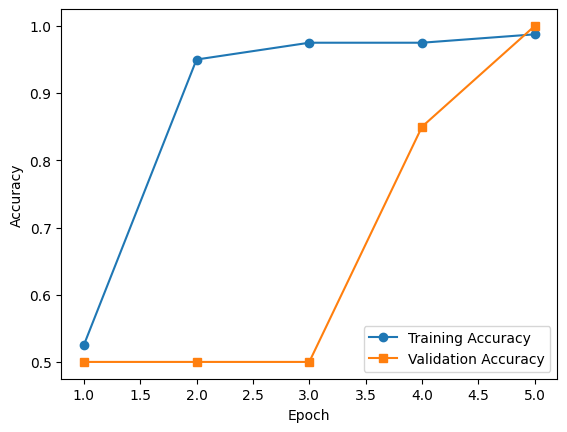

In [ ]:
plt.plot(epochs_range, train_mse, marker='o', label='Training MSE')
plt.plot(epochs_range, val_mse, marker='s', label='Validation MSE')
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.show()

plt.plot(epochs_range, train_acc, marker='o', label='Training Accuracy')
plt.plot(epochs_range, val_acc, marker='s', label='Validation Accuracy')
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()
